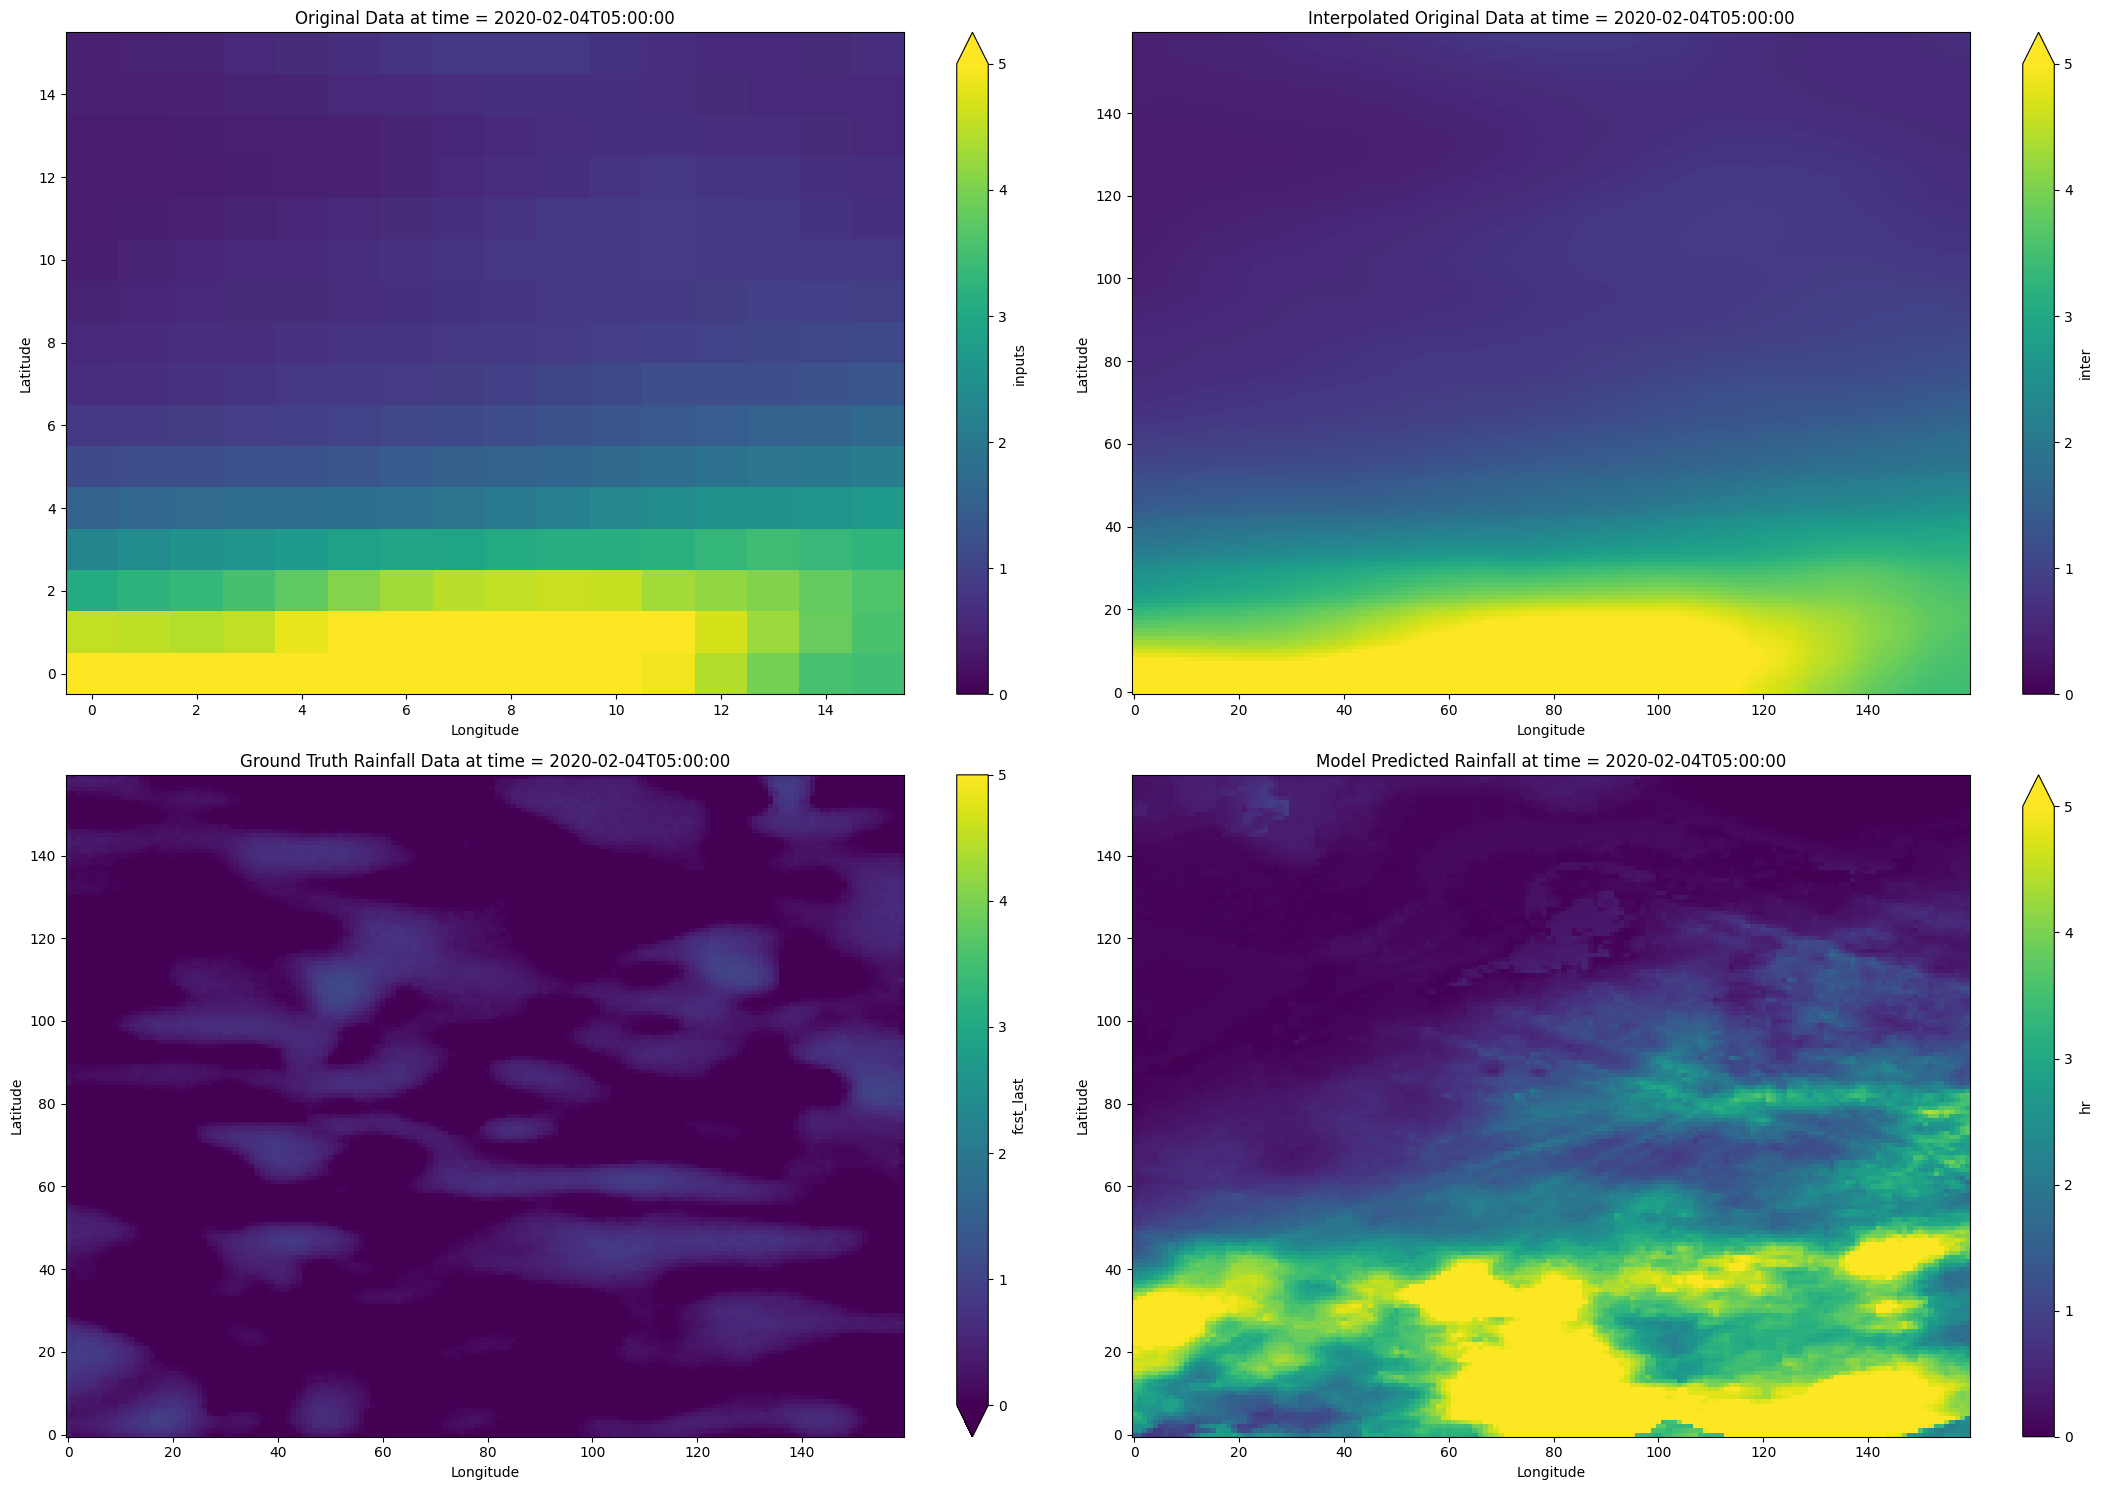

In [10]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex36_onestepdiffusion_zscorenormlazie_timestep300_l2_aheadtop_0.008_150epoch/prcp_downs_diffusion_year_2020.nc")
time_index = 380 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["fcst_last"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["hr"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


In [2]:
import xarray as xs
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/prcp_downs_diffusion_year_2020.nc")
ds

<xarray.Dataset>
Dimensions:     (time: 6912, lat_in: 16, lon_in: 16, lat: 160, lon: 160,
                 pitch_idx: 6912)
Coordinates:
  * time        (time) datetime64[ns] 2020-02-01T06:00:00 ... 2020-12-01T02:0...
  * pitch_idx   (pitch_idx) int32 1 2 3 4 5 6 ... 6907 6908 6909 6910 6911 6912
Dimensions without coordinates: lat_in, lon_in, lat, lon
Data variables: (12/13)
    inputs      (time, lat_in, lon_in) float32 ...
    fcst        (time, lat, lon) float32 ...
    fcst_first  (time, lat, lon) float32 ...
    fcst_last   (time, lat, lon) float32 ...
    fcst_50     (time, lat, lon) float32 ...
    fcst_100    (time, lat, lon) float32 ...
    ...          ...
    refe        (time, lat, lon) float32 ...
    noiseP      (time, lat, lon) float32 ...
    hr          (time, lat, lon) float32 ...
    inter       (time, lat, lon) float32 ...
    lats        (time, lat) float32 ...
    lons        (time, lon) float32 ...
Attributes:
    description:  Precipitation downscaling data.

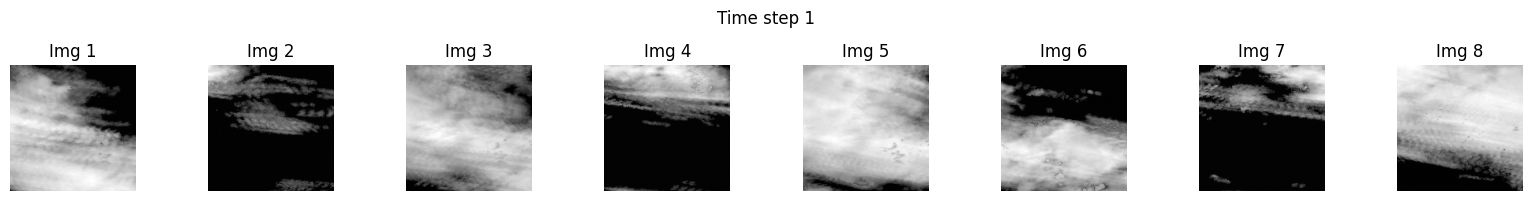

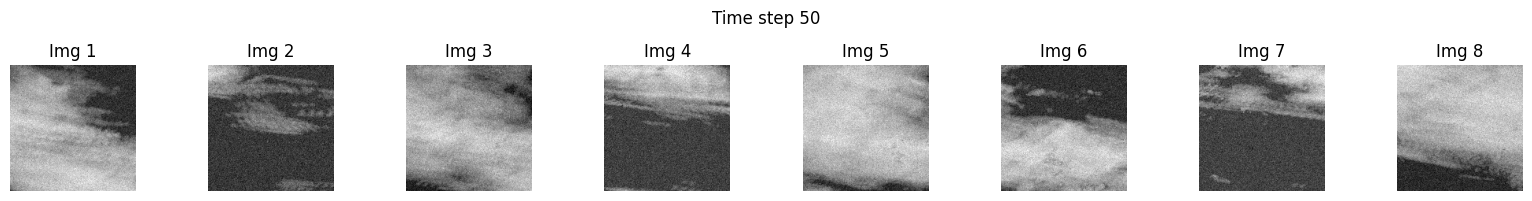

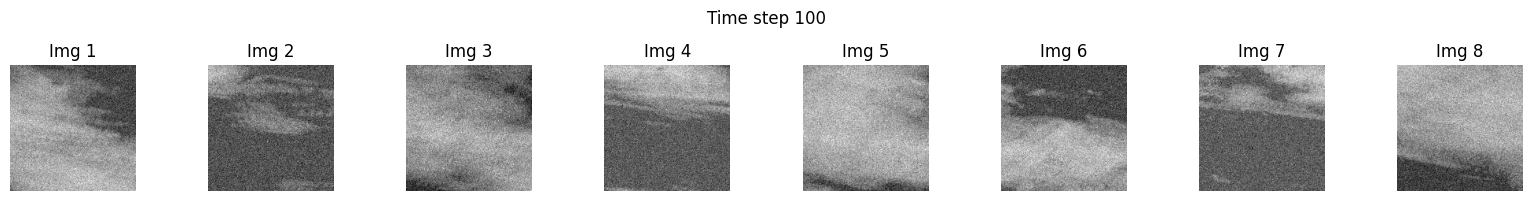

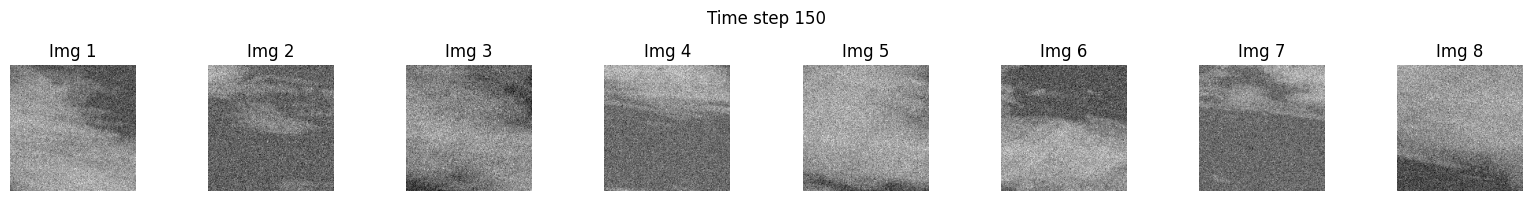

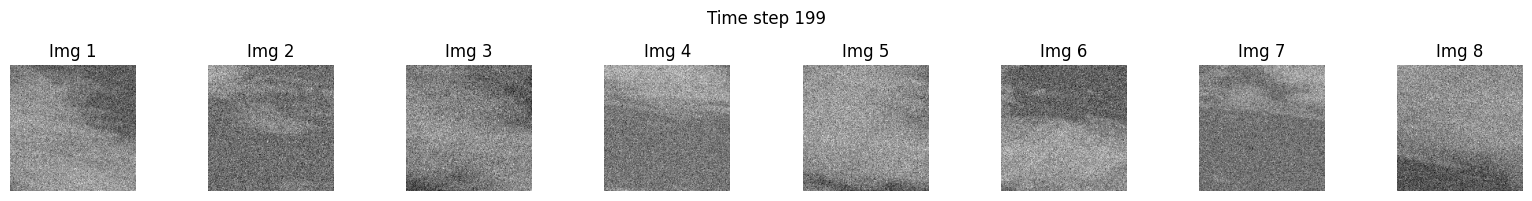

In [23]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_images(base_dir, idx, time_steps):
    for time_step in time_steps:
        fig, axes = plt.subplots(1, 8, figsize=(16, 2))  # 为8张图像创建子图
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            # Assuming noise_images is an ndarray of shape (8, 1, 160, 160)
        for i, img in enumerate(noise_images):
            img = img.squeeze()  # Remove channel dimension, resulting in (160, 160)
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'Img {i+1}')
            axes[i].axis('off')
        plt.suptitle(f'Time step {time_step}')
        plt.tight_layout()
        plt.show()

# Usage example
base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex35_onestepdiffusion_zscorenormlazie_l2_aheadtop_0.008_150epoch/noise_samples'
idx = 0  # Example index
time_steps = [1, 50, 100, 150, 199]  # Time steps you saved
load_and_plot_images(base_dir, idx, time_steps)



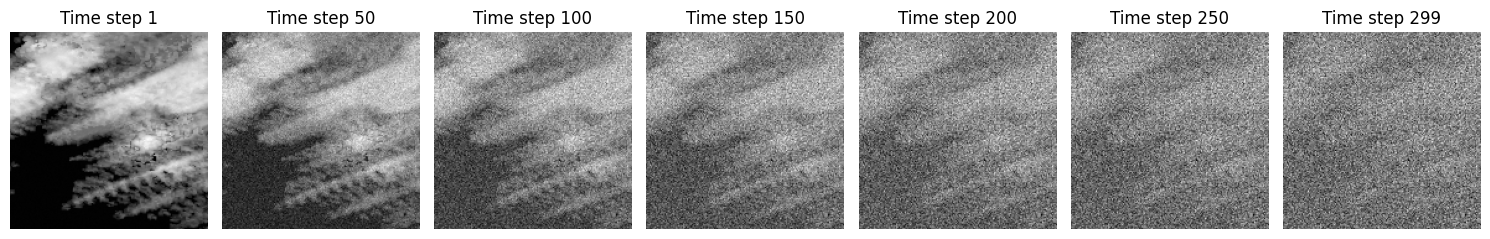

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_first_image(base_dir, idx, time_steps):
    fig, axes = plt.subplots(1, len(time_steps), figsize=(15, 3))
    for i, time_step in enumerate(time_steps):
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            # Assuming noise_images is an ndarray of shape (24, 1, 160, 160)
            # Select the first image of the batch and remove channel dimension
            img = noise_images[1].squeeze()  # First image, shape should be (160, 160)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Time step {time_step}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Usage example
base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex36_onestepdiffusion_zscorenormlazie_timestep300_l2_aheadtop_0.008_150epoch/noise_samples'
idx = 0  # Example index
time_steps = [1, 50, 100, 150, 200, 250,299]  # Time steps you saved
load_and_plot_first_image(base_dir, idx, time_steps)


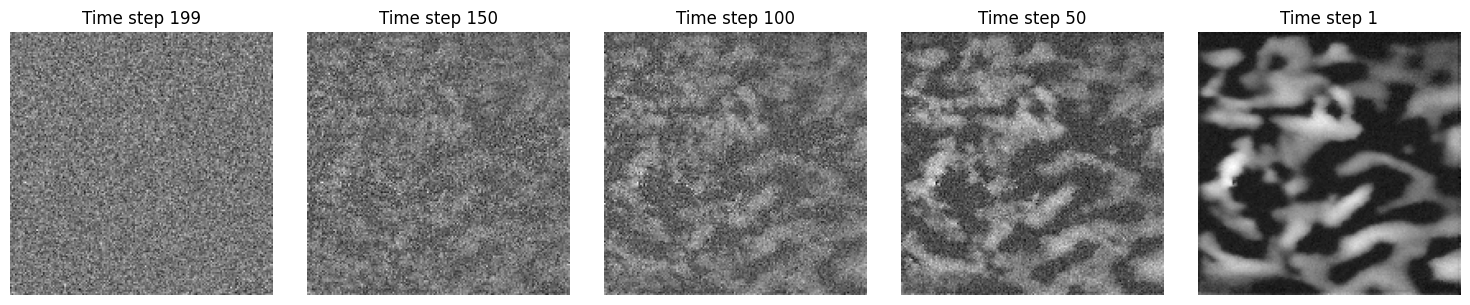

In [38]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_first_image(base_dir, idx, time_steps):
    fig, axes = plt.subplots(1, len(time_steps), figsize=(15, 3))
    for i, time_step in enumerate(time_steps):
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_denoise_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            # Assuming noise_images is an ndarray of shape (24, 1, 160, 160)
            # Select the first image of the batch and remove channel dimension
            img = noise_images[0].squeeze()  # First image, shape should be (160, 160)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Time step {time_step}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Usage example
base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex35_onestepdiffusion_zscorenormlazie_l2_aheadtop_0.008_150epoch/denoise_samples'
idx = 0  # Example index
time_steps = [199, 150, 100, 50, 1]  # Time steps you saved
load_and_plot_first_image(base_dir, idx, time_steps)

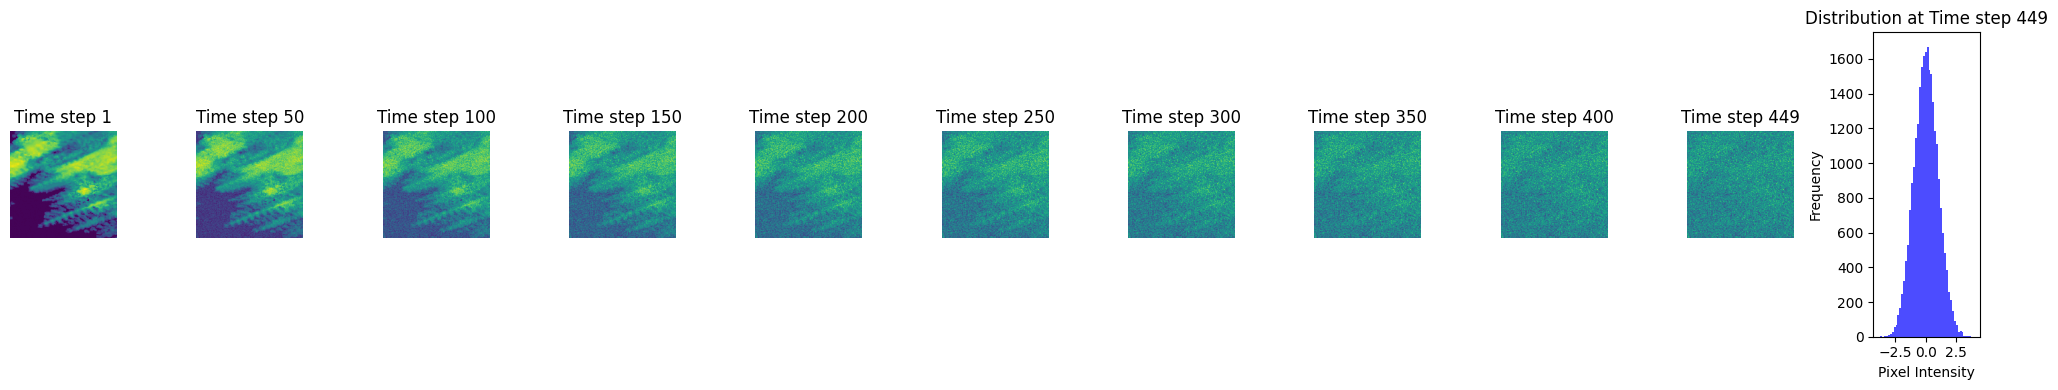

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_images_with_histogram(base_dir, idx, time_steps):
    fig, axes = plt.subplots(1, len(time_steps) + 1, figsize=(20, 4))  # Adding space for one more subplot for the histogram
    for i, time_step in enumerate(time_steps):
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            img = noise_images[1].squeeze()  # First image, assume shape (160, 160) after squeezing
        axes[i].imshow(img)
        axes[i].set_title(f'Time step {time_step}')
        axes[i].axis('off')

    # Load the image at the last time step to plot histogram
    last_image_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{449}.pkl')
    with open(last_image_path, 'rb') as f:
        last_images = pickle.load(f)
        last_img = last_images[1].squeeze()

    # Plot histogram of the last image
    axes[-1].hist(last_img.flatten(), bins=50, color='blue', alpha=0.7)
    axes[-1].set_title('Distribution at Time step 449')
    axes[-1].set_xlabel('Pixel Intensity')
    axes[-1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex37_onestepdiffusion_zscorenormlazie_timestep450_l2_aheadtop_0.008_150epoch/noise_samples'
idx = 0  # Example index
time_steps = [1, 50, 100, 150, 200, 250, 300, 350,400,449]
load_and_plot_images_with_histogram(base_dir, idx, time_steps)


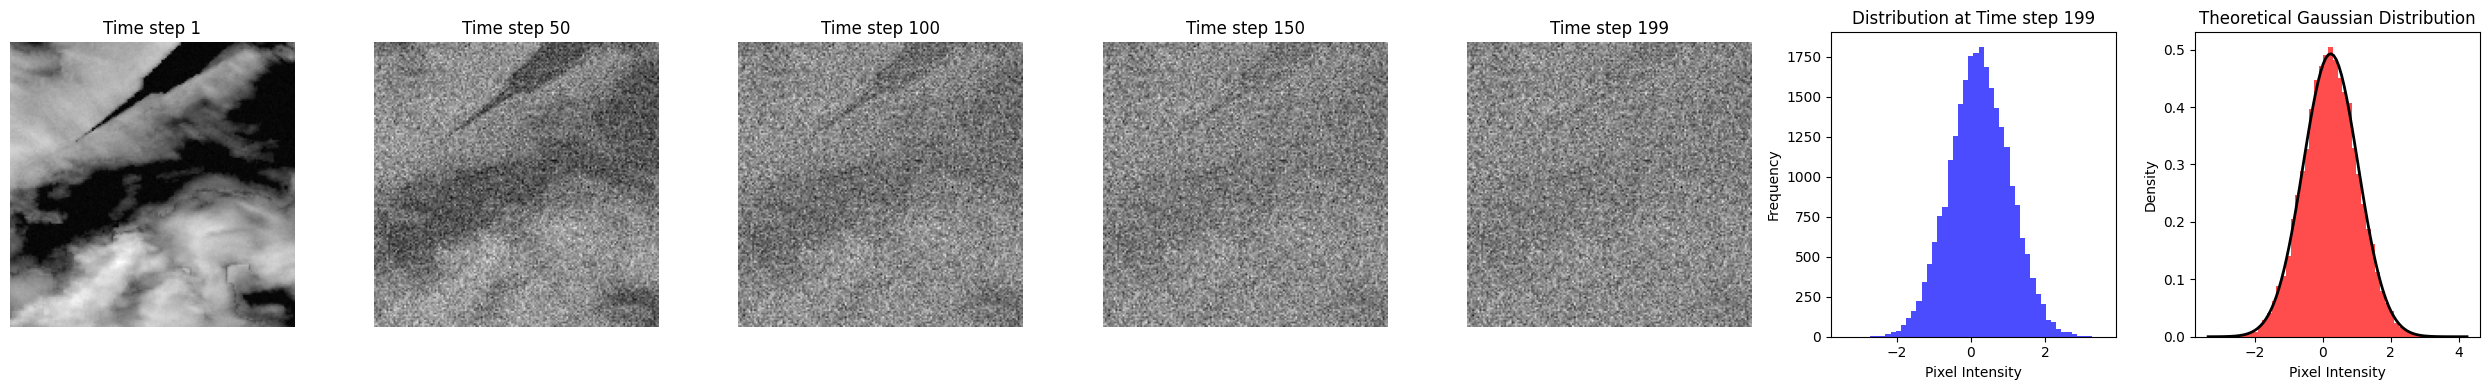

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.stats as stats  # 导入scipy.stats进行高斯分布的计算

def load_and_plot_images_with_histogram_and_gaussian(base_dir, idx, time_steps):
    fig, axes = plt.subplots(1, len(time_steps) + 2, figsize=(25, 4))  # 增加一个额外的子图位
    for i, time_step in enumerate(time_steps):
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            img = noise_images[0].squeeze()
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Time step {time_step}')
        axes[i].axis('off')

    # 加载第199步的图像并绘制直方图
    last_image_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{199}.pkl')
    with open(last_image_path, 'rb') as f:
        last_images = pickle.load(f)
        last_img = last_images[0].squeeze()

    # 绘制直方图
    data = last_img.flatten()
    axes[-2].hist(data, bins=50, color='blue', alpha=0.7)
    axes[-2].set_title('Distribution at Time step 199')
    axes[-2].set_xlabel('Pixel Intensity')
    axes[-2].set_ylabel('Frequency')

    # 生成理论的高斯分布直方图
    mean, std = np.mean(data), np.std(data)
    theoretical_dist = np.random.normal(mean, std, size=data.shape)
    axes[-1].hist(theoretical_dist, bins=50, color='red', alpha=0.7, density=True)
    axes[-1].set_title('Theoretical Gaussian Distribution')
    axes[-1].set_xlabel('Pixel Intensity')
    axes[-1].set_ylabel('Density')

    # 在高斯分布上绘制正态曲线
    xmin, xmax = axes[-1].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mean, std)
    axes[-1].plot(x, p, 'k', linewidth=2)

    plt.tight_layout()
    plt.show()

base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/noise_samples'
idx = 0
time_steps = [1, 50, 100, 150, 199]
load_and_plot_images_with_histogram_and_gaussian(base_dir, idx, time_steps)


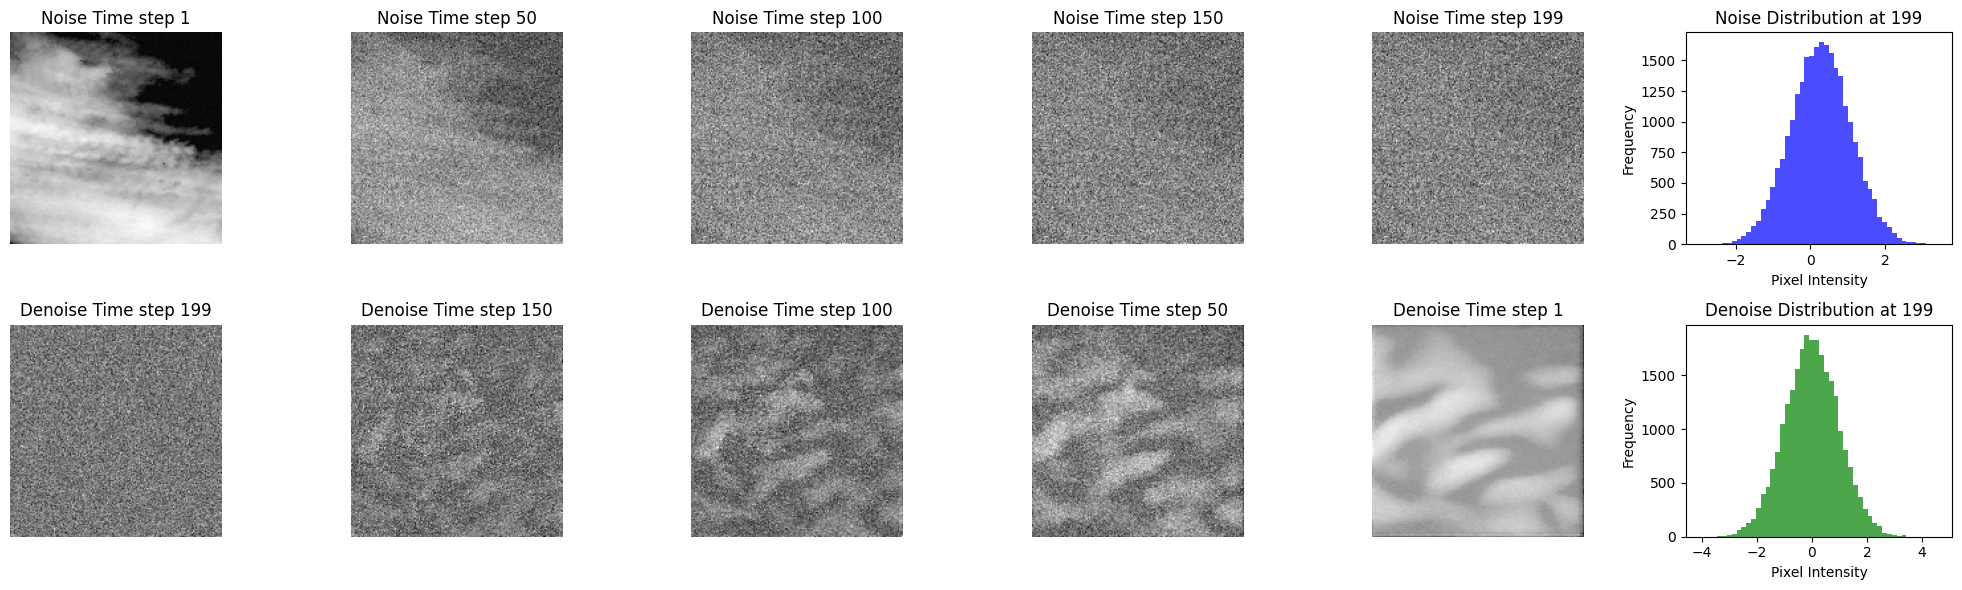

In [16]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_images_with_histogram(base_dir, denoise_dir, idx, time_steps):
    fig, axes = plt.subplots(2, len(time_steps) + 1, figsize=(20, 6))  # Allocate subplots, last column for histogram

    # Plot noisy images
    for i, time_step in enumerate(time_steps):
        file_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            noise_images = pickle.load(f)
            img = noise_images[0].squeeze()  # First image
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Noise Time step {time_step}')
        axes[0, i].axis('off')

    # Plot denoised images
    for i, time_step in enumerate(reversed(time_steps)):
        file_path = os.path.join(denoise_dir, f'example_5132_idx_{idx}_denoise_t_{time_step}.pkl')
        with open(file_path, 'rb') as f:
            denoise_images = pickle.load(f)
            img = denoise_images[0].squeeze()  # First image
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'Denoise Time step {time_step}')
        axes[1, i].axis('off')

    # Load the image at the last time step to plot histogram for both noisy and denoised
    last_image_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_199.pkl')
    last_denoise_path = os.path.join(denoise_dir, f'example_5132_idx_{idx}_denoise_t_199.pkl')

    with open(last_image_path, 'rb') as f:
        last_images = pickle.load(f)
        last_img = last_images[0].squeeze()

    with open(last_denoise_path, 'rb') as f:
        last_denoise_images = pickle.load(f)
        last_denoise_img = last_denoise_images[0].squeeze()

    # Plot histogram of the last noisy and denoised image
    axes[0, -1].hist(last_img.flatten(), bins=50, color='blue', alpha=0.7)
    axes[0, -1].set_title('Noise Distribution at 199')
    axes[0, -1].set_xlabel('Pixel Intensity')
    axes[0, -1].set_ylabel('Frequency')

    axes[1, -1].hist(last_denoise_img.flatten(), bins=50, color='green', alpha=0.7)
    axes[1, -1].set_title('Denoise Distribution at 199')
    axes[1, -1].set_xlabel('Pixel Intensity')
    axes[1, -1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Usage example
base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/noise_samples'
denoise_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/denoise_samples'
idx = 0  # Example index
time_steps = [1, 50, 100, 150, 199]  # Time steps i saved
load_and_plot_images_with_histogram(base_dir, denoise_dir, idx, time_steps)



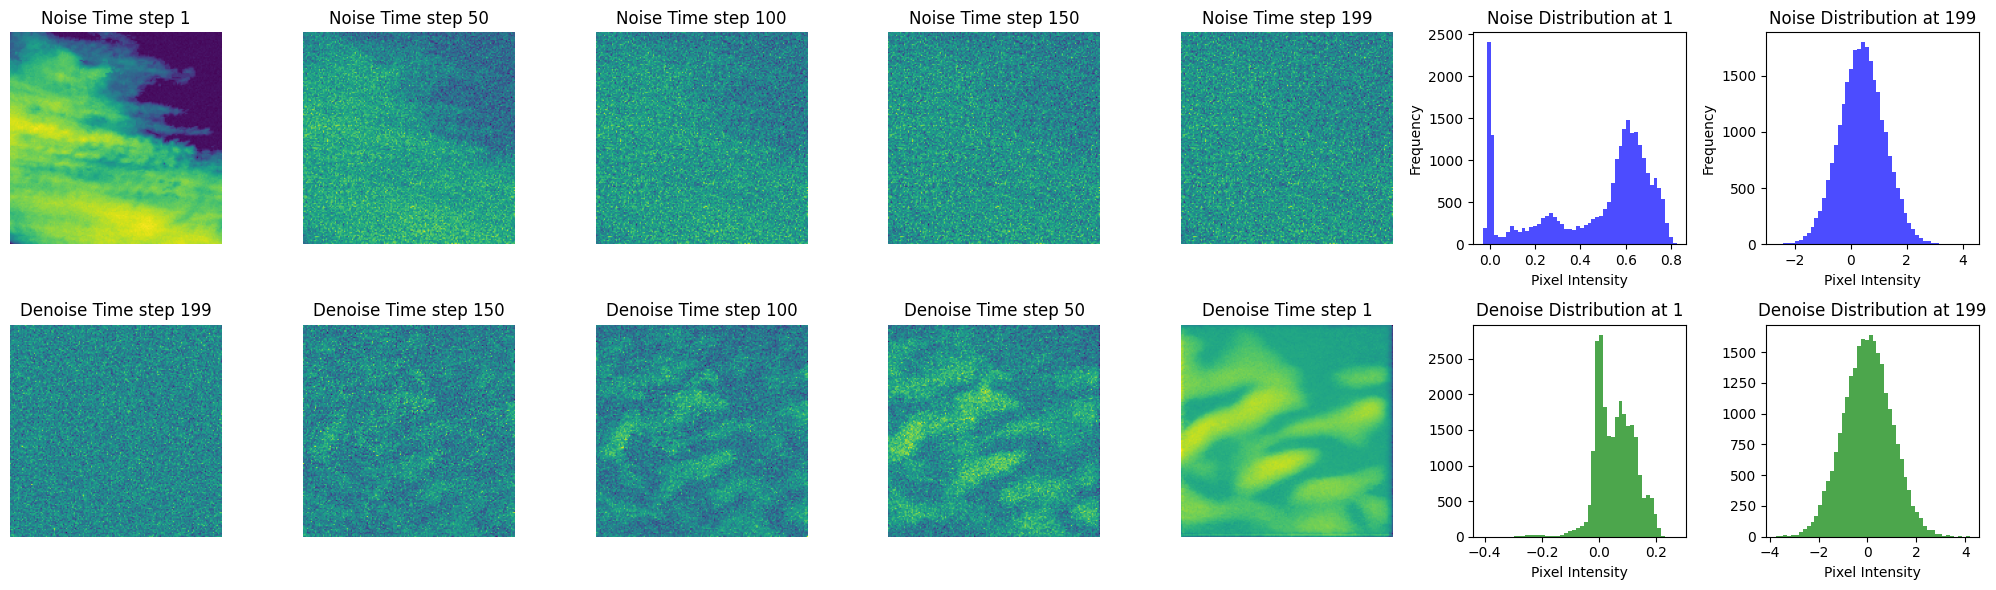

In [14]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os

def load_and_plot_combined_images(base_dir, denoise_dir, idx, time_steps):
    fig, axes = plt.subplots(2, len(time_steps) + 2, figsize=(20, 6))  # 为图像和直方图分配subplot

    # 处理每一个时间步
    for i, time_step in enumerate(time_steps):
        # 加噪声图像的路径
        noisy_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        # 去噪声图像的路径
        denoise_path = os.path.join(denoise_dir, f'example_5132_idx_{idx}_denoise_t_{time_step}.pkl')

        # 加载并显示加噪声图像
        with open(noisy_path, 'rb') as f:
            noisy_images = pickle.load(f)
            noisy_img = noisy_images[0].squeeze()
        axes[0, i].imshow(noisy_img, cmap='viridis')  # 使用'viridis'颜色映射
        axes[0, i].set_title(f'Noise Time step {time_step}')
        axes[0, i].axis('off')

    # 去噪声图像的显示顺序调整为反向
    reversed_time_steps = list(reversed(time_steps))
    for i, time_step in enumerate(reversed_time_steps):
        # 加载并显示去噪声图像
        denoise_path = os.path.join(denoise_dir, f'example_5132_idx_{idx}_denoise_t_{time_step}.pkl')
        with open(denoise_path, 'rb') as f:
            denoise_images = pickle.load(f)
            denoise_img = denoise_images[0].squeeze()
        axes[1, i].imshow(denoise_img, cmap='viridis')  # 使用'viridis'颜色映射
        axes[1, i].set_title(f'Denoise Time step {time_step}')
        axes[1, i].axis('off')

    # 绘制第1步和第199步的数据分布直方图
    for idx, time_step in enumerate([1, 199]):
        noisy_path = os.path.join(base_dir, f'example_5132_idx_{idx}_t_{time_step}.pkl')
        with open(noisy_path, 'rb') as f:
            noisy_images = pickle.load(f)
            noisy_img = noisy_images[0].squeeze()
        axes[0, len(time_steps) + idx].hist(noisy_img.flatten(), bins=50, color='blue', alpha=0.7)
        axes[0, len(time_steps) + idx].set_title(f'Noise Distribution at {time_step}')
        axes[0, len(time_steps) + idx].set_xlabel('Pixel Intensity')
        axes[0, len(time_steps) + idx].set_ylabel('Frequency')

        denoise_path = os.path.join(denoise_dir, f'example_5132_idx_{idx}_denoise_t_{time_step}.pkl')
        with open(denoise_path, 'rb') as f:
            denoise_images = pickle.load(f)
            denoise_img = denoise_images[0].squeeze()
        axes[1, len(time_steps) + idx].hist(denoise_img.flatten(), bins=50, color='green', alpha=0.7)
        axes[1, len(time_steps) + idx].set_title(f'Denoise Distribution at {time_step}')
        axes[1, len(time_steps) + idx].set_xlabel('Pixel Intensity')

    plt.tight_layout()
    plt.show()

base_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/noise_samples'
denoise_dir = '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex34_onestepdiffusion_addnormlazie_l2_aheadtop_0.008_150epoch/denoise_samples'
idx = 0  # Example index
time_steps = [1, 50, 100, 150, 199] 
load_and_plot_combined_images(base_dir, denoise_dir, idx, time_steps)
